## what would have happened in terms of weather if I was doing my trip in the 1950? let's find it out

##### precipitation_sum (mm)	temperature_2m_mean (°C)	wind_speed_10m_max (km/h)	wind_direction_10m_dominant (°)

In [16]:
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cmocean

df = pd.read_csv('/Users/filippomichelon/Documents/PersonalCode-local-utils/patagonia-trip-utils/openmeteo_data/track_viaggioneltempo/day_data.csv', sep=";")
ids = pd.read_csv('/Users/filippomichelon/Documents/PersonalCode-local-utils/patagonia-trip-utils/openmeteo_data/track_viaggioneltempo/day_id.csv', sep=";")

# Converte la colonna 'time' in datetime 
df["time"] = pd.to_datetime(df["time"])

# Crea una colonna temporanea con mese e giorno
df["mmdd"] = df["time"].dt.strftime("%m-%d")
df["year"] = df["time"].dt.year


# Converte la colonna 'time' in datetime 
ids["time"] = pd.to_datetime(ids["date"])

# Crea una colonna temporanea con mese e giorno
ids["mmdd"] = ids["time"].dt.strftime("%m-%d")
ids["year"] = ids["time"].dt.year


# select only days of interest for every location

In [4]:
filtered_list = []

for location in ids.location_id:
    filtered_df = df[(df["location_id"] == location) & (df["mmdd"] == ids.mmdd[location])]
    filtered_list.append(filtered_df)
    
# Unisci tutti i DataFrame filtrati
result_df = pd.concat(filtered_list, ignore_index=True)
result_df

,location_id,time,rain,temp,wind_speed,wind_dir,mmdd,year
0,0,1941-02-10,0.0,15.3,8.9,308,02-10,1941
1,0,1942-02-10,2.1,9.0,13.2,315,02-10,1942
2,0,1943-02-10,1.7,13.9,9.7,329,02-10,1943
3,0,1944-02-10,0.0,15.7,7.6,313,02-10,1944
4,0,1945-02-10,0.0,14.0,7.7,317,02-10,1945
...,...,...,...,...,...,...,...,...
1695,19,2021-03-04,0.0,17.5,7.7,116,03-04,2021
1696,19,2022-03-04,4.7,11.1,14.0,291,03-04,2022
1697,19,2023-03-04,0.0,14.5,10.1,314,03-04,2023
1698,19,2024-03-04,0.0,14.8,8.4,72,03-04,2024


# work now on plotting

In [5]:
result_df[result_df["year"] == 2025].mmdd

84      02-10
169     02-11
254     02-12
339     02-13
424     02-14
509     02-15
594     02-16
679     02-17
764     02-18
849     02-20
934     02-22
1019    02-23
1104    02-24
1189    02-25
1274    02-26
1359    02-27
1444    02-28
1529    03-01
1614    03-03
1699    03-04
Name: mmdd, dtype: object

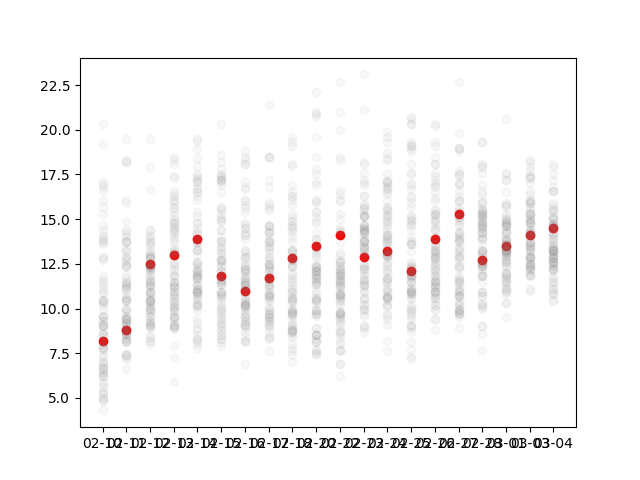

In [6]:
plt.figure()
plt.scatter(result_df[result_df["year"] == 2025].mmdd, result_df[result_df["year"] == 2025].temp ,c = "red")
plt.scatter(result_df.mmdd, result_df.temp, alpha= .05, c= "grey")

(array([0.0078064 , 0.        , 0.0039032 , 0.0117096 , 0.0273224 ,
        0.04683841, 0.03903201, 0.07025761, 0.08196721, 0.10148322,
        0.12880562, 0.10928962, 0.12099922, 0.15612802, 0.12099922,
        0.08196721, 0.09758002, 0.07806401, 0.05074161, 0.04683841,
        0.08977361, 0.05464481, 0.0234192 , 0.03512881, 0.0156128 ,
        0.0078064 , 0.0117096 , 0.0039032 , 0.0039032 , 0.0117096 ]),
 array([ 4.8 ,  5.41,  6.02,  6.63,  7.24,  7.85,  8.46,  9.07,  9.68,
        10.29, 10.9 , 11.51, 12.12, 12.73, 13.34, 13.95, 14.56, 15.17,
        15.78, 16.39, 17.  , 17.61, 18.22, 18.83, 19.44, 20.05, 20.66,
        21.27, 21.88, 22.49, 23.1 ]),
 <BarContainer object of 30 artists>)

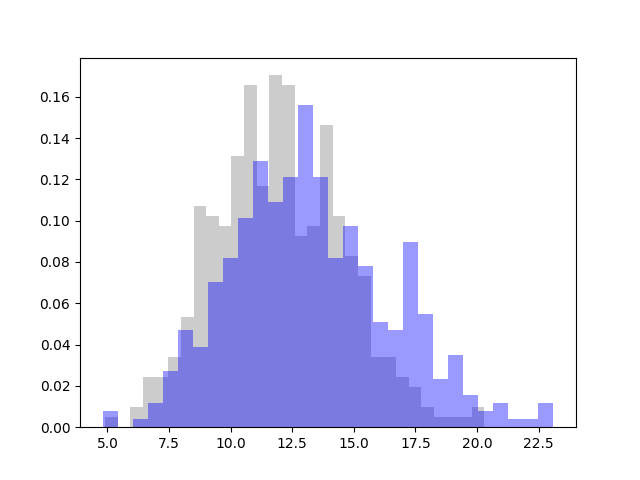

In [7]:
plt.figure()
plt.hist(result_df[(result_df["year"] >= 1940) & (result_df["year"] <= 1960)].temp,
    bins=30,
    density=True,  # ← Normalizza l'area a 1
    color='grey',
    alpha = .4,)

plt.hist(result_df[(result_df["year"] >= 2000) & (result_df["year"] <= 2020)].temp,
    bins=30,
    density=True,  # ← Normalizza l'area a 1
    color='blue',
    alpha = .4,)



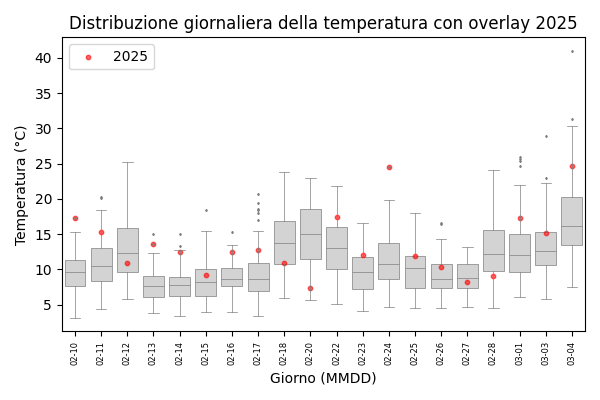

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assicurati che mmdd sia ordinato
result_df["mmdd"] = pd.Categorical(result_df["mmdd"], ordered=True, categories=sorted(result_df["mmdd"].unique()))

plt.figure(figsize=(6, 4))

# 1. Boxplot per tutti gli anni
sns.boxplot(data=result_df, x="mmdd", y="wind_speed", color="lightgrey", fliersize=1, linewidth=0.5)

# 2. Overlay: scatter plot per il 2025
plt.scatter(
    result_df[result_df["year"] == 2025].mmdd,
    result_df[result_df["year"] == 2025].wind_speed,
    color="red",
    label="2025",
    alpha=0.6,
    s=10
)

# Migliora la leggibilità
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("Giorno (MMDD)")
plt.ylabel("Temperatura (°C)")
plt.title("Distribuzione giornaliera della temperatura con overlay 2025")
plt.legend()
plt.tight_layout()

plt.show()


In [9]:
result_df

,location_id,time,rain,temp,wind_speed,wind_dir,mmdd,year
0,0,1941-02-10,0.0,15.3,8.9,308,02-10,1941
1,0,1942-02-10,2.1,9.0,13.2,315,02-10,1942
2,0,1943-02-10,1.7,13.9,9.7,329,02-10,1943
3,0,1944-02-10,0.0,15.7,7.6,313,02-10,1944
4,0,1945-02-10,0.0,14.0,7.7,317,02-10,1945
...,...,...,...,...,...,...,...,...
1695,19,2021-03-04,0.0,17.5,7.7,116,03-04,2021
1696,19,2022-03-04,4.7,11.1,14.0,291,03-04,2022
1697,19,2023-03-04,0.0,14.5,10.1,314,03-04,2023
1698,19,2024-03-04,0.0,14.8,8.4,72,03-04,2024


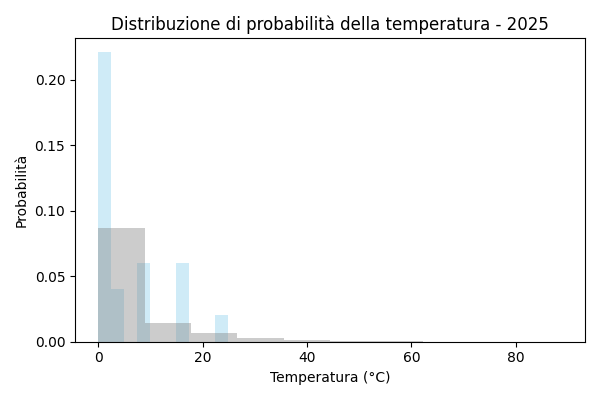

In [10]:

# Crea la figura
fig = plt.figure(figsize=(6, 4))

# Istogramma normalizzato (probabilità)
plt.hist(
    result_df[result_df["year"] == 2025].rain,
    bins=10,
    density=True,  # ← Normalizza l'area a 1
    color='skyblue',
    alpha = .4,
)

# Istogramma normalizzato (probabilità)
plt.hist(
    result_df.rain,
    bins=10,
    density=True,  # ← Normalizza l'area a 1
    color='grey',
    alpha = .4,
)


# Etichette e titolo
plt.xlabel("Temperatura (°C)")
plt.ylabel("Probabilità")
plt.title("Distribuzione di probabilità della temperatura - 2025")

plt.tight_layout()



In [11]:

result_df

,location_id,time,rain,temp,wind_speed,wind_dir,mmdd,year
0,0,1941-02-10,0.0,15.3,8.9,308,02-10,1941
1,0,1942-02-10,2.1,9.0,13.2,315,02-10,1942
2,0,1943-02-10,1.7,13.9,9.7,329,02-10,1943
3,0,1944-02-10,0.0,15.7,7.6,313,02-10,1944
4,0,1945-02-10,0.0,14.0,7.7,317,02-10,1945
...,...,...,...,...,...,...,...,...
1695,19,2021-03-04,0.0,17.5,7.7,116,03-04,2021
1696,19,2022-03-04,4.7,11.1,14.0,291,03-04,2022
1697,19,2023-03-04,0.0,14.5,10.1,314,03-04,2023
1698,19,2024-03-04,0.0,14.8,8.4,72,03-04,2024


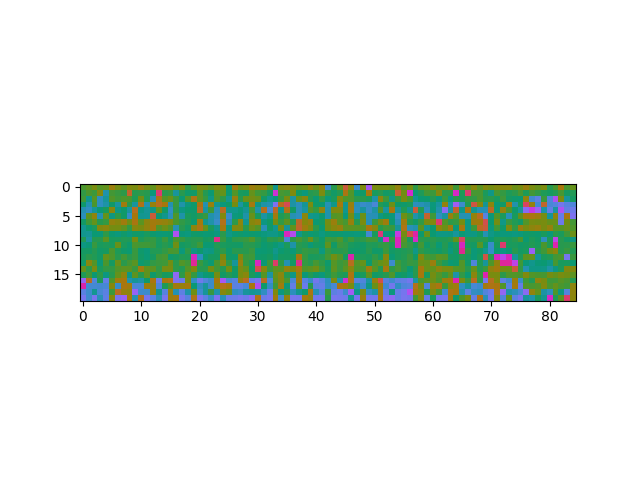

In [20]:
filt_list = []

for year in result_df.year.unique():
    filt_df = result_df[result_df["year"] == year].wind_dir
    filt_list.append(filt_df)


# Creo una lista di array numpy da ogni serie temp filtrata per anno
arrays = [filt_df.values for filt_df in filt_list]

# Creo la matrice 2D: righe=anno, colonne=giorni (assumendo tutti uguali in lunghezza)
matrix = np.vstack(arrays)

# opzionale: indici anni
years = sorted(result_df["year"].unique())

# Creo DataFrame pandas per una visualizzazione migliore

matrix_df = pd.DataFrame(matrix, index=years)

cmap = cmocean.cm.phase

plt.figure()
plt.imshow(matrix_df.T , cmap = cmap)


##### imagesc with temperature of all years

In [ ]:
# 1. Calcola la media giornaliera per city + year + mmdd
df_daymean = df_season.groupby(["city", "year", "mmdd"])["temp"].mean().reset_index()

# 2. Crea un dizionario di matrici, una per ogni città
matrices = {
    city: group.pivot(index="year", columns="mmdd", values="temp")
    for city, group in df_daymean.groupby("city")
}

c = sns.diverging_palette(220, 20, as_cmap=True)
#c = sns.color_palette("cubehelix", as_cmap=True)
# Estrai la matrice
matrix = matrices["Villa_O_Higgings"]


plt.figure(figsize= (7,2))
im = plt.imshow(matrix.T, cmap = c,aspect='auto')
plt.title('Villa O\'Higgins')

plt.colorbar(im, label="Temperature (°C)")  # or use another label as needed


# Etichette assi
plt.ylabel("Day of Season")

# Tick personalizzati (opzionale)
# Estrai la matrice

# Mostra un'etichetta ogni 2 anni
plt.xticks(
    ticks=range(0, len(matrix.index), 15),
    labels=matrix.index[::15],  # ogni due anni
    rotation=45
)
plt.yticks(ticks=range(0, len(matrix.columns), 7),
           labels=[matrix.columns[i] for i in range(0, len(matrix.columns), 7)]
)

plt.tight_layout()

### wind speed plot here